## Analysis 1 - Career Slugging Percentage by Birth Country
### Which country produces players with the greatest average hitting power?

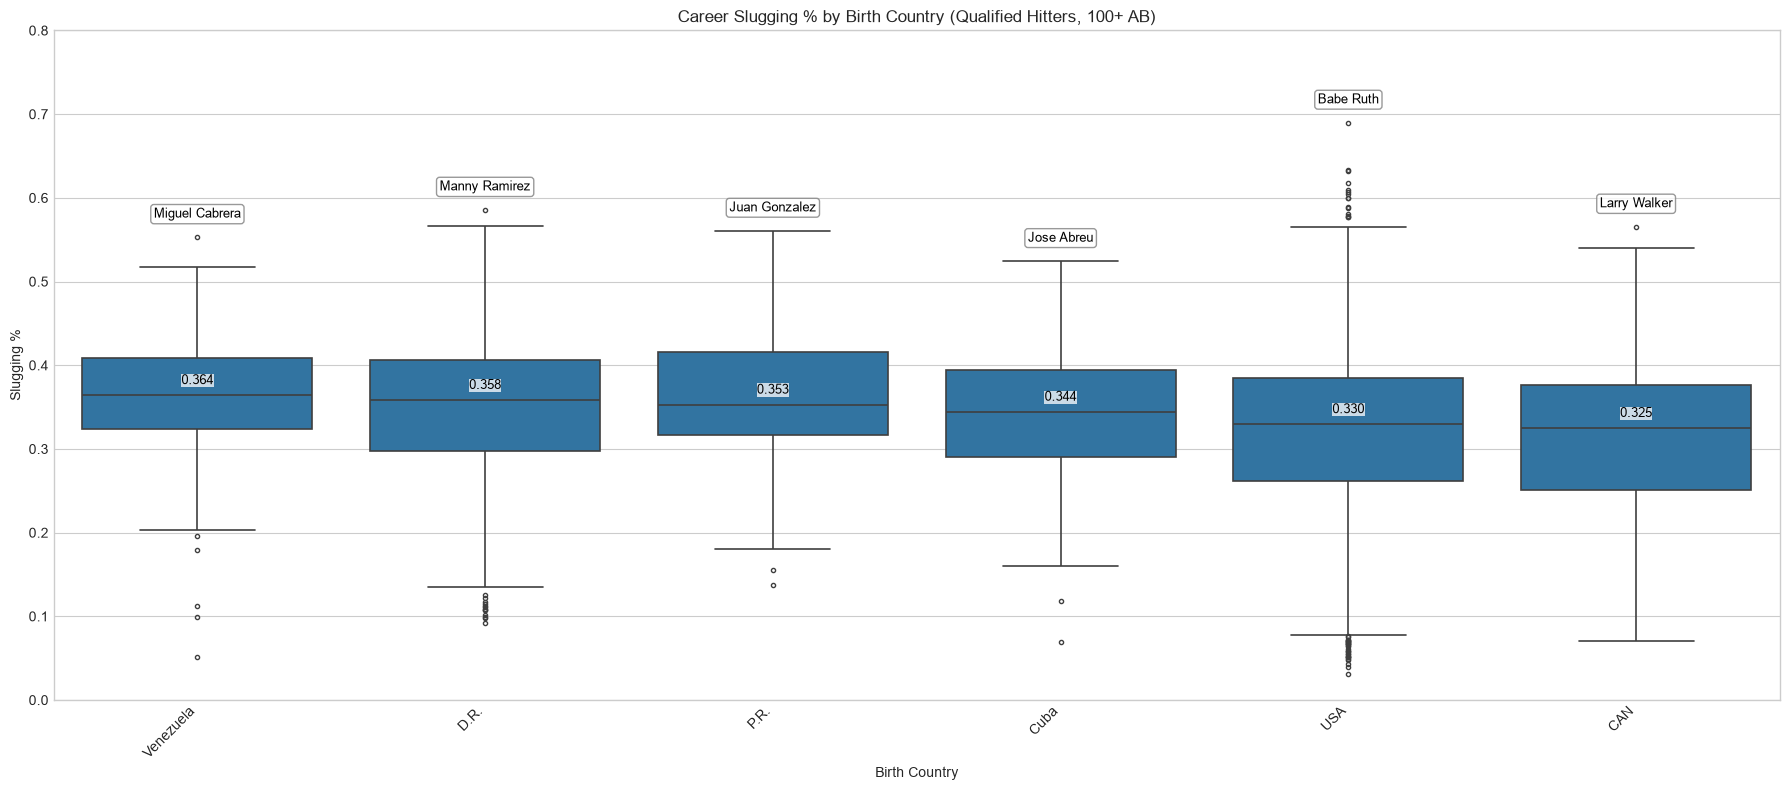


Analysis 1 summary:
              count      mean    median
birthCountry                           
USA            7759  0.320682  0.329516
D.R.            280  0.343502  0.358467
Venezuela       169  0.358665  0.364243
P.R.            161  0.361050  0.352831
Cuba            107  0.338065  0.344413
CAN             103  0.314174  0.325000


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Load required datasets
batting = pd.read_csv(Path("core") / "Batting.csv")
people = pd.read_csv(Path("core") / "People.csv")

# Normalize numeric columns
for df, cols in [
    (batting, ["AB", "H", "2B", "3B", "HR"]),
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------------------------------------------------
# Analysis 1: Slugging % vs Birth Country
# -----------------------------------------------------------------------------
# Build career totals for each player using all seasons
batting_career = batting[["playerID", "AB", "H", "2B", "3B", "HR"]].copy()
for col in ["AB", "H", "2B", "3B", "HR"]:
    batting_career[col] = batting_career[col].fillna(0)

career_stats = (
    batting_career.groupby("playerID", as_index=False)
    .sum(numeric_only=True)
    .merge(people[["playerID", "birthCountry"]], on="playerID", how="left")
)

career_stats["singles"] = career_stats["H"] - career_stats["2B"] - career_stats["3B"] - career_stats["HR"]
career_stats["slugging_pct"] = (
    career_stats["singles"] + 2 * career_stats["2B"] + 3 * career_stats["3B"] + 4 * career_stats["HR"]
) / career_stats["AB"]

# Restrict to qualified hitters with 100+ AB and valid birth countries
qualified_players = career_stats[
    (career_stats["AB"] >= 100)
    & (career_stats["birthCountry"].notna())
    & (career_stats["birthCountry"] != "")
].copy()

country_counts = qualified_players["birthCountry"].value_counts()
eligible_countries = country_counts[country_counts >= 100].index
qualified_players = qualified_players[qualified_players["birthCountry"].isin(eligible_countries)].copy()
qualified_players = qualified_players.merge(
    people[["playerID", "nameFirst", "nameLast"]],
    on="playerID",
    how="left",
)

country_order = (
    qualified_players.groupby("birthCountry")["slugging_pct"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Identify the top slugging player in each country for annotation
country_top_players = (
    qualified_players.sort_values(["birthCountry", "slugging_pct"], ascending=[True, False])
    .drop_duplicates("birthCountry")
    .sort_values("birthCountry")
    .reset_index(drop=True)
)
country_top_players["x_pos"] = country_top_players["birthCountry"].map(
    {country: idx for idx, country in enumerate(country_order)}
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=qualified_players,
    x="birthCountry",
    y="slugging_pct",
    order=country_order,
    linewidth=1.2,
    flierprops={"marker": "o", "markersize": 3},
    ax=ax,
)

# Add labels for each median value
for idx, country in enumerate(country_order):
    median_value = qualified_players.loc[
        qualified_players["birthCountry"] == country,
        "slugging_pct",
    ].median()
    ax.text(
        idx,
        median_value + 0.01,
        f"{median_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.2},
    )

# Label the highest-slugging player for each country
for _, row in country_top_players.iterrows():
    player_name = f"{row['nameFirst']} {row['nameLast']}".strip()
    ax.annotate(
        player_name,
        (row["x_pos"], row["slugging_pct"]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
        bbox={"facecolor": "white", "edgecolor": "gray", "alpha": 0.8, "boxstyle": "round,pad=0.25"},
    )

ax.set_title("Career Slugging % by Birth Country (Qualified Hitters, 100+ AB)")
ax.set_xlabel("Birth Country")
ax.set_ylabel("Slugging %")
ax.set_ylim(0, 0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Summary of countries with 100+ qualified hitters
country_summary = (
    qualified_players.groupby("birthCountry")["slugging_pct"]
    .agg(["count", "mean", "median"])
    .sort_values(["count", "median"], ascending=[False, False])
)
print("\nAnalysis 1 summary:")
print(country_summary.to_string())

## Analysis 2 - Career Slugging Percentage vs Career Batting Average

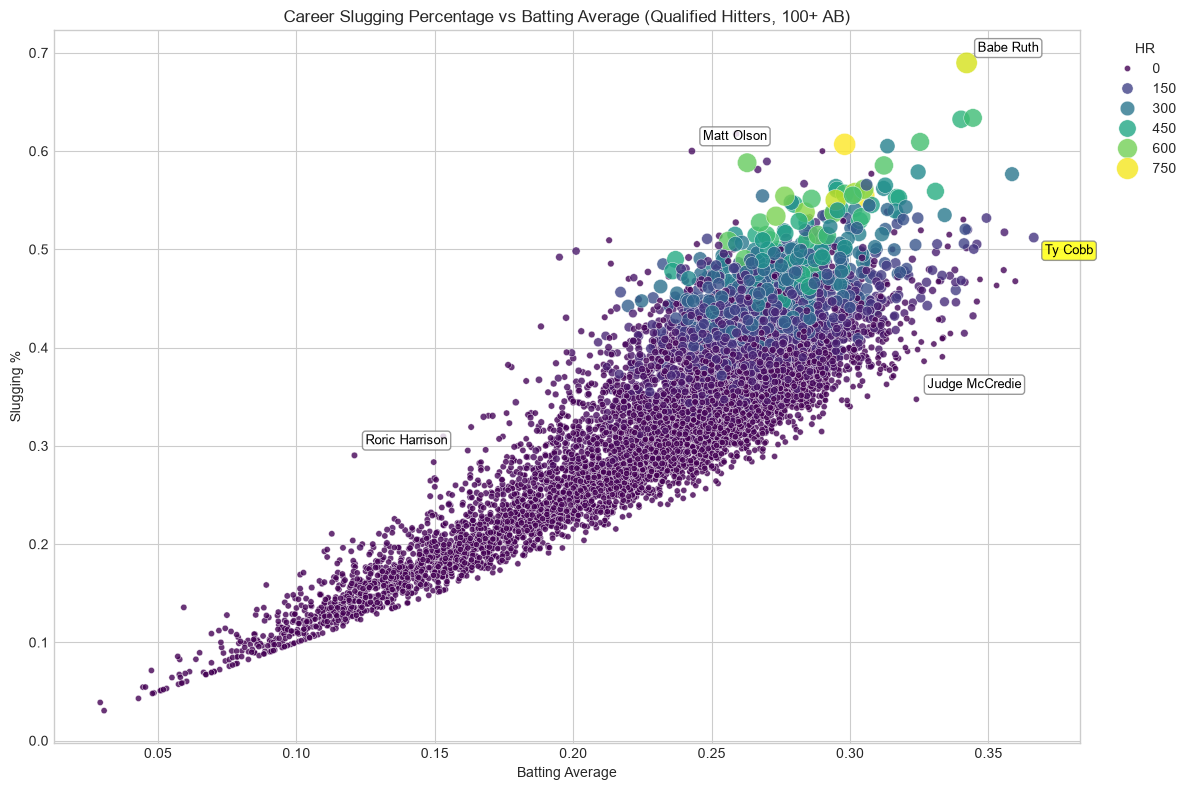


Analysis 2 sample of top 10 players by slugging:
 playerID   AB    H  HR  batting_avg  slugging_pct
 ruthba01 8398 2873 714     0.342105      0.689807
willite01 7706 2654 521     0.344407      0.633792
gehrilo01 8001 2721 493     0.340082      0.632421
hoskirh01  170   44  18     0.258824      0.617647
 foxxji01 8134 2646 534     0.325301      0.609294
bondsba01 9847 2935 762     0.298060      0.606885
greenha01 5193 1628 331     0.313499      0.605045
 bassjo01  100   29   3     0.290000      0.600000
olsonma02  210   51  24     0.242857      0.600000
judgeaa01  626  169  56     0.269968      0.589457


In [3]:

# -----------------------------------------------------------------------------
# Analysis 2: Career batting average vs slugging percentage
# -----------------------------------------------------------------------------
qualified_players["batting_avg"] = qualified_players["H"] / qualified_players["AB"]

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=qualified_players,
    x="batting_avg",
    y="slugging_pct",
    hue="HR",
    size="HR",
    sizes=(20, 250),
    palette="viridis",
    alpha=0.8,
    ax=ax,
)
ax.set_title("Career Slugging Percentage vs Batting Average (Qualified Hitters, 100+ AB)")
ax.set_xlabel("Batting Average")
ax.set_ylabel("Slugging %")
ax.legend(title="HR", bbox_to_anchor=(1.02, 1), loc="upper left")

# Label selected outliers and the maximum batting average player
interesting_points = [
    (0.12, 0.29),
    (0.34, 0.69),
    (0.325, 0.35),
    (0.24, 0.6),
]

# Helper to find the closest actual player to each requested point
annotated_players = []

for target_x, target_y in interesting_points:
    candidate_df = qualified_players[["playerID", "nameFirst", "nameLast", "batting_avg", "slugging_pct"]].copy()
    candidate_df["distance"] = ((candidate_df["batting_avg"] - target_x) ** 2 + (candidate_df["slugging_pct"] - target_y) ** 2) ** 0.5
    nearest_row = candidate_df.sort_values("distance").iloc[0]

    if nearest_row["playerID"] not in annotated_players:
        player_name = f"{nearest_row['nameFirst']} {nearest_row['nameLast']}".strip()
        ax.annotate(
            player_name,
            (nearest_row["batting_avg"], nearest_row["slugging_pct"]),
            xytext=(8, 8),
            textcoords="offset points",
            fontsize=9,
            color="black",
            bbox={"facecolor": "white", "edgecolor": "gray", "alpha": 0.8, "boxstyle": "round,pad=0.25"},
        )
        annotated_players.append(nearest_row["playerID"])

highest_ba_row = qualified_players.sort_values("batting_avg", ascending=False).iloc[0]
highest_ba_name = f"{highest_ba_row['nameFirst']} {highest_ba_row['nameLast']}".strip()
ax.annotate(
    highest_ba_name,
    (highest_ba_row["batting_avg"], highest_ba_row["slugging_pct"]),
    xytext=(8, -12),
    textcoords="offset points",
    fontsize=9,
    color="black",
    bbox={"facecolor": "yellow", "edgecolor": "gray", "alpha": 0.8, "boxstyle": "round,pad=0.25"},
)

plt.tight_layout()
plt.show()

print("\nAnalysis 2 sample of top 10 players by slugging:")
print(
    qualified_players[["playerID", "AB", "H", "HR", "batting_avg", "slugging_pct"]]
    .sort_values("slugging_pct", ascending=False)
    .head(10)
    .to_string(index=False)
)


## Analysis 3: How has offense changed over time?

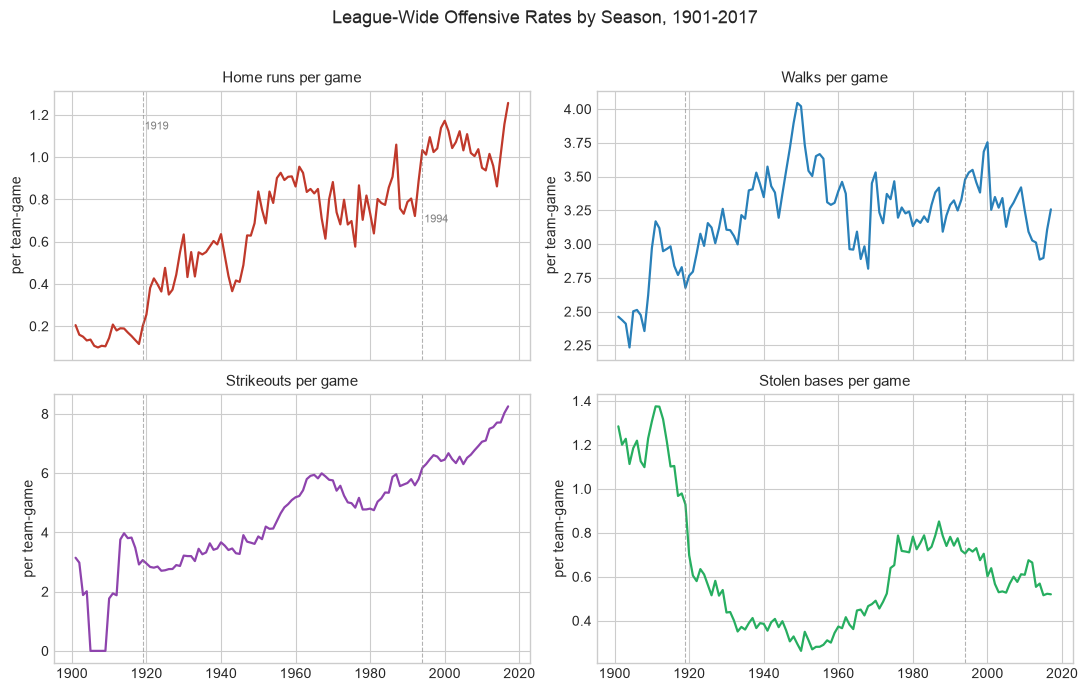

        HR_pg  BB_pg  SO_pg  SB_pg
yearID                            
1901    0.205  2.462  3.143  1.284
1930    0.634  3.106  3.216  0.437
1968    0.614  2.817  5.890  0.466
1994    1.033  3.478  6.177  0.706
2000    1.172  3.754  6.455  0.602
2017    1.256  3.257  8.252  0.520


In [4]:
teams = pd.read_csv(Path("core")/"Teams.csv", low_memory=False)

modern = teams[(teams["yearID"] >= 1901) & (teams["G"] > 0)].copy()

yearly = modern.groupby("yearID").apply(
    lambda x: pd.Series({
        "HR_pg": x["HR"].sum() / x["G"].sum(),
        "BB_pg": x["BB"].sum() / x["G"].sum(),
        "SO_pg": x["SO"].sum() / x["G"].sum(),
        "SB_pg": x["SB"].sum() / x["G"].sum(),
    }),
    include_groups=False,
)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
panels = [
    ("HR_pg", "Home runs per game", "#c0392b"),
    ("BB_pg", "Walks per game", "#2980b9"),
    ("SO_pg", "Strikeouts per game", "#8e44ad"),
    ("SB_pg", "Stolen bases per game", "#27ae60"),
]

era_markers = {
    1919: "Live-ball era begins",
    1994: "Start of ‘steroid era’ offensive surge",
}

for ax, (col, title, color) in zip(axes.flat, panels):
    ax.plot(yearly.index, yearly[col], color=color, linewidth=1.6)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("per team-game")
    for yr in era_markers:
        ax.axvline(yr, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

axes[0, 0].text(1919.5, yearly["HR_pg"].max()*0.9, "1919", fontsize=8, color="gray")
axes[0, 0].text(1994.5, yearly["HR_pg"].max()*0.55, "1994", fontsize=8, color="gray")

fig.suptitle("League-Wide Offensive Rates by Season, 1901-2017", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(yearly.loc[[1901, 1930, 1968, 1994, 2000, 2017]].round(3))

## Analysis 4: What team stats actually correlate with winning?

## Legend
* WinPct: Wins / Games
### Per Game
* RunDiff: (Runs Scored - Runs Allowed) / Games (difference in the scores per game)
* R: Runs
* RA: Runs Allowed
* HR: Home Runs
* BB: Walks by Batters
* SB: Stolen Bases
* BatterSO: team's own hitters striking out
* PitcherSO: team's pitchers striking out batter

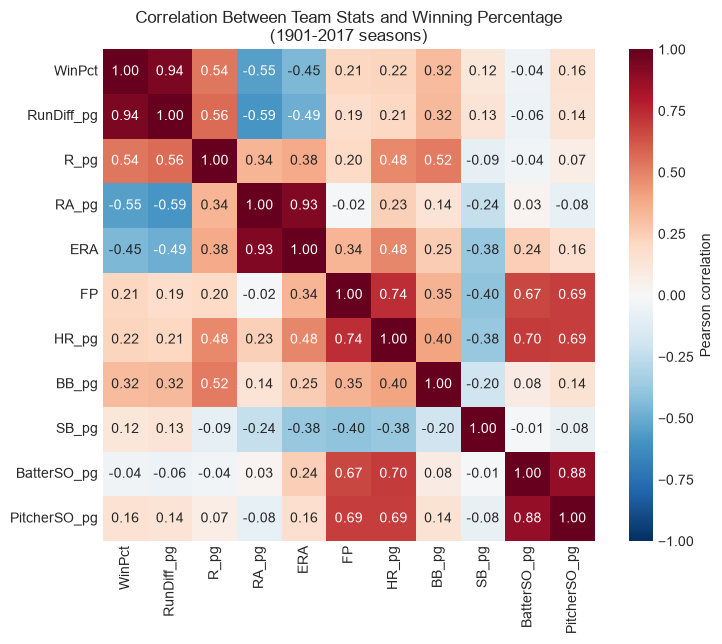

RunDiff_pg      0.944854
R_pg            0.535612
BB_pg           0.316055
HR_pg           0.220936
FP              0.213984
PitcherSO_pg    0.156104
SB_pg           0.121297
BatterSO_pg    -0.039361
ERA            -0.448133
RA_pg          -0.552635
Name: WinPct, dtype: float64

In [5]:
teams = pd.read_csv(Path("core") / "Teams.csv")

stats = teams[(teams["yearID"] >= 1901) & (teams["G"] > 0)].copy()

stats["WinPct"] = stats["W"] / stats["G"]
stats["RunDiff_pg"] = (stats["R"] - stats["RA"]) / stats["G"]
stats["R_pg"] = stats["R"] / stats["G"]
stats["RA_pg"] = stats["RA"] / stats["G"]
stats["HR_pg"] = stats["HR"] / stats["G"]
stats["BB_pg"] = stats["BB"] / stats["G"]
stats["SB_pg"] = stats["SB"] / stats["G"]
stats["BatterSO_pg"] = stats["SO"] / stats["G"]
stats["PitcherSO_pg"] = stats["SOA"] / stats["G"]

corr_cols = ["WinPct", "RunDiff_pg", "R_pg", "RA_pg", "ERA", "FP",
             "HR_pg", "BB_pg", "SB_pg", "BatterSO_pg", "PitcherSO_pg"]
corr_matrix = stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation Between Team Stats and Winning Percentage\n(1901-2017 seasons)", fontsize=12)
plt.tight_layout()
plt.show()

corr_matrix["WinPct"].drop("WinPct").sort_values(ascending=False)